# Day 61: Random Forest — sklearn + Feature Importance
**Phase 4 · Machine Learning** | Dataset: FC Lahore Lions matches (synthetic, seed = 42)

## Objective
By the end of this notebook I should be able to:
- Fit `RandomForestClassifier(n_estimators=100, random_state=42)` and predict
- Plot `feature_importances_` as a **horizontal bar chart sorted by importance**
- Use the **OOB score** (`oob_score=True`) as a free validation estimate
- Compare a **single decision tree vs a random forest** on the same data: accuracy and importances
- Know the main **limit of `feature_importances_`** and check it with permutation importance

## Imports

In [1]:
# numpy and pandas for data
import numpy as np
import pandas as pd

# matplotlib for charts
import matplotlib.pyplot as plt

# the two models, the splitter, and evaluation tools
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.inspection import permutation_importance

plt.rcParams["axes.grid"] = True

## Theory
- **Recap (Day 60):** a Random Forest = many trees, each trained on a bootstrap sample, each split using only a random subset of features, combined by majority vote. Today, sklearn does all of that in one line.
- **`RandomForestClassifier(n_estimators=100, random_state=42)`**
  - `n_estimators` = number of trees.
  - `random_state=42` makes the randomness repeatable.
  - Use it exactly like the other sklearn models: `.fit()`, `.predict()`, `.score()`.
- **`feature_importances_`:** for each feature, the average impurity reduction it gave across all trees, scaled to sum to 1. Averaging over many trees makes it steadier than the single-tree version from Day 59.
- **OOB score (`oob_score=True`):** each tree never sees about 37% of the training rows (Day 60). The forest predicts each row using only the trees that did **not** train on it, then scores those predictions. It is a validation estimate that needs no separate split.
- **Limit of `feature_importances_`:** it is calculated from the *training* data, and it tends to favour features with many distinct values, even useless ones. **Permutation importance** (shuffle one column of the *test* data and see how much the score drops) is a good cross-check.

**Football picture:** 100 scouts each judge the squad from a different set of matches and a different set of stats. Feature importance is asking the whole scouting room, "which stat did you lean on most?" OOB is checking each scout's opinion only on matches he never watched.

## Example 1: Fit, Predict and Evaluate

In [2]:
# Synthetic data: 500 matches (same dataset as Days 59 and 60)
rng = np.random.default_rng(42)                      # seed = 42 so results repeat
n_matches = 500

shots = rng.integers(0, 13, size=n_matches)          # shots on target
possession = rng.integers(35, 66, size=n_matches)    # possession %
pass_accuracy = rng.integers(70, 93, size=n_matches) # pass accuracy %
home_game = rng.integers(0, 2, size=n_matches)       # 1 = home, 0 = away
opponent_rank = rng.integers(1, 21, size=n_matches)  # 1 = strongest opponent
kickoff_hour = rng.integers(12, 22, size=n_matches)  # NOT linked to the result, on purpose

z = (0.45 * shots + 0.04 * (possession - 50) + 0.7 * home_game
     + 0.10 * (opponent_rank - 10) - 3.0)
won = rng.binomial(1, 1 / (1 + np.exp(-z)))

df = pd.DataFrame({
    "match_id": np.arange(1, n_matches + 1),
    "shots_on_target": shots, "possession_pct": possession,
    "pass_accuracy_pct": pass_accuracy, "home_game": home_game,
    "opponent_rank": opponent_rank, "kickoff_hour": kickoff_hour, "won": won
})

# Save next to the notebook, then read it back
df.to_csv("day_61_fc_lahore_lions_matches.csv", index=False)
df = pd.read_csv("day_61_fc_lahore_lions_matches.csv")

X = df.drop(columns=["match_id", "won"])
y = df["won"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print("Train:", len(X_train), "| Test:", len(X_test))

Train: 375 | Test: 125


In [3]:
# Fit the forest and predict on unseen test data
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print("Train accuracy:", round(rf.score(X_train, y_train), 3))
print("Test accuracy: ", round(rf.score(X_test, y_test), 3))

Train accuracy: 1.0
Test accuracy:  0.76


In [4]:
# Confusion matrix and classification report (Day 55 tools)
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=["Loss", "Win"]))

[[52 10]
 [20 43]]

              precision    recall  f1-score   support

        Loss       0.72      0.84      0.78        62
         Win       0.81      0.68      0.74        63

    accuracy                           0.76       125
   macro avg       0.77      0.76      0.76       125
weighted avg       0.77      0.76      0.76       125



## Example 2: Feature Importances

In [5]:
# feature_importances_ as a sorted Series
rf_importances = pd.Series(rf.feature_importances_, index=X.columns)
rf_importances = rf_importances.sort_values(ascending=False)

print(rf_importances.round(3))
print("Sum of importances:", round(rf_importances.sum(), 3))

shots_on_target      0.442
possession_pct       0.154
opponent_rank        0.139
pass_accuracy_pct    0.128
kickoff_hour         0.105
home_game            0.032
dtype: float64
Sum of importances: 1.0


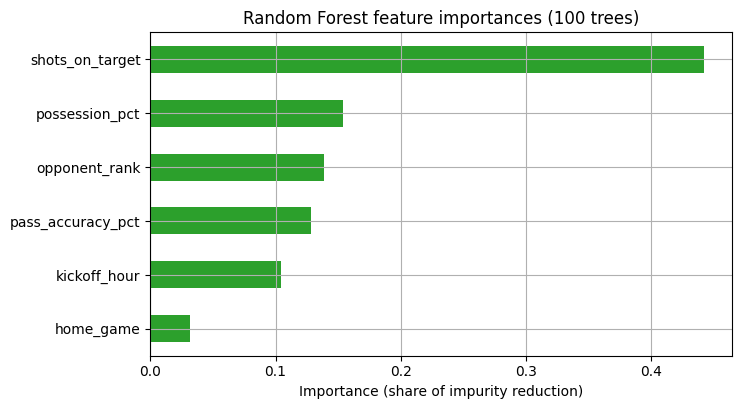

In [6]:
# Chart: horizontal bar chart sorted by importance
plt.figure(figsize=(7.5, 4.2))
rf_importances.sort_values().plot(kind="barh", color="tab:green")
plt.xlabel("Importance (share of impurity reduction)")
plt.title("Random Forest feature importances (100 trees)")
plt.savefig("images/rf_feature_importances.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# Are the importances stable? Refit with three different seeds and compare the top feature
for seed in [0, 1, 2]:
    m = RandomForestClassifier(n_estimators=100, random_state=seed).fit(X_train, y_train)
    imp = pd.Series(m.feature_importances_, index=X.columns).sort_values(ascending=False)
    print("seed", seed, "| top:", imp.index[0], round(imp.iloc[0], 3),
          "| kickoff_hour:", round(imp["kickoff_hour"], 3))

seed 0 | top: shots_on_target 0.445 | kickoff_hour: 0.107
seed 1 | top: shots_on_target 0.448 | kickoff_hour: 0.102


seed 2 | top: shots_on_target 0.435 | kickoff_hour: 0.108


## Example 3: OOB Score, a Free Validation Estimate

In [8]:
# oob_score=True: score every training row using only the trees that never saw it
rf_oob = RandomForestClassifier(n_estimators=100, random_state=42, oob_score=True)
rf_oob.fit(X_train, y_train)

print("OOB score:     ", round(rf_oob.oob_score_, 3))
print("Test accuracy: ", round(rf_oob.score(X_test, y_test), 3))
# Two different estimates of unseen-data accuracy that land in the same area.

OOB score:      0.781
Test accuracy:  0.76


In [9]:
# How does the OOB score change with the number of trees?
tree_counts = [10, 25, 50, 100, 200, 500]
oob_scores, test_scores = [], []
for n in tree_counts:
    m = RandomForestClassifier(n_estimators=n, random_state=42, oob_score=True)
    m.fit(X_train, y_train)
    oob_scores.append(m.oob_score_)
    test_scores.append(m.score(X_test, y_test))
    print(f"{n:>4} trees | OOB {m.oob_score_:.3f} | test {test_scores[-1]:.3f}")

  10 trees | OOB 0.723 | test 0.744


  25 trees | OOB 0.771 | test 0.768
  50 trees | OOB 0.781 | test 0.768


 100 trees | OOB 0.781 | test 0.760


 200 trees | OOB 0.779 | test 0.768


 500 trees | OOB 0.773 | test 0.768


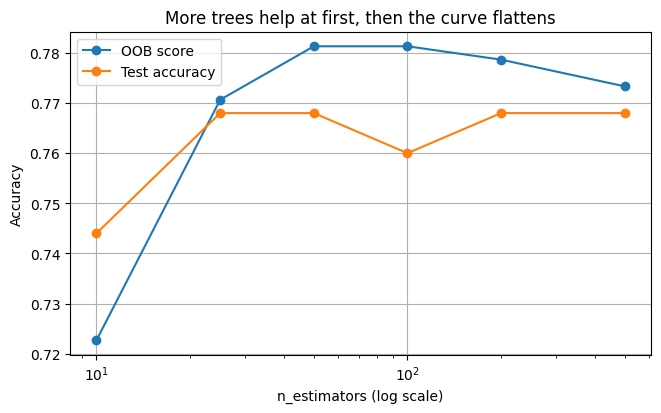

In [10]:
# Chart: OOB and test accuracy against the number of trees
plt.figure(figsize=(7.5, 4.2))
plt.plot(tree_counts, oob_scores, marker="o", label="OOB score")
plt.plot(tree_counts, test_scores, marker="o", label="Test accuracy")
plt.xscale("log")
plt.xlabel("n_estimators (log scale)")
plt.ylabel("Accuracy")
plt.title("More trees help at first, then the curve flattens")
plt.legend()
plt.savefig("images/oob_vs_n_estimators.png", dpi=150, bbox_inches="tight")
plt.show()

## Example 4: Single Decision Tree vs Random Forest

In [11]:
# Same data, same split, same random_state
tree = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)

print("Model          | train acc | test acc")
print(f"Decision tree  | {tree.score(X_train, y_train):.3f}     | {tree.score(X_test, y_test):.3f}")
print(f"Random forest  | {rf.score(X_train, y_train):.3f}     | {rf.score(X_test, y_test):.3f}")

Model          | train acc | test acc
Decision tree  | 1.000     | 0.672
Random forest  | 1.000     | 0.760


In [12]:
# 5-fold CV on the training set, a steadier comparison than one split (Day 57 pattern)
cv_tree = cross_val_score(DecisionTreeClassifier(random_state=42), X_train, y_train, cv=5)
cv_rf = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42), X_train, y_train, cv=5)

print("Decision tree CV:", cv_tree.round(3), "| mean:", round(cv_tree.mean(), 3))
print("Random forest CV:", cv_rf.round(3), "| mean:", round(cv_rf.mean(), 3))

Decision tree CV: [0.747 0.72  0.707 0.707 0.773] | mean: 0.731
Random forest CV: [0.76  0.787 0.787 0.813 0.813] | mean: 0.792


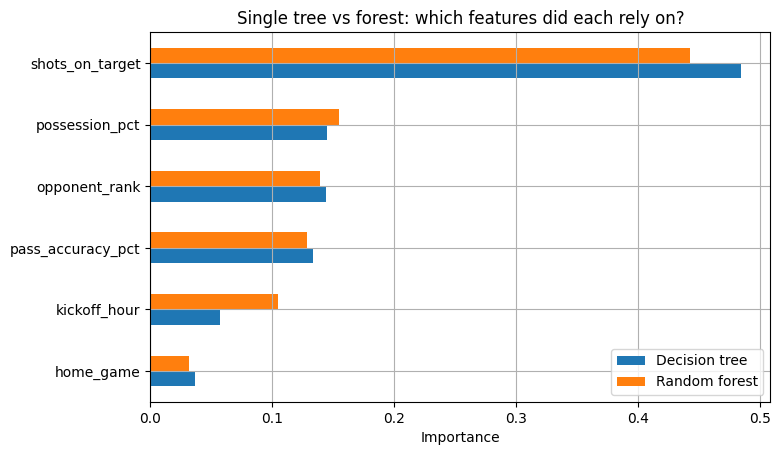

                   Decision tree  Random forest
shots_on_target            0.484          0.442
possession_pct             0.145          0.154
opponent_rank              0.144          0.139
pass_accuracy_pct          0.133          0.128
kickoff_hour               0.057          0.105
home_game                  0.037          0.032


In [13]:
# Chart: importances of the tree vs the forest, side by side
tree_importances = pd.Series(tree.feature_importances_, index=X.columns)
compare = pd.DataFrame({"Decision tree": tree_importances, "Random forest": rf_importances})
compare = compare.sort_values("Random forest")

compare.plot(kind="barh", figsize=(8, 4.8))
plt.xlabel("Importance")
plt.title("Single tree vs forest: which features did each rely on?")
plt.savefig("images/tree_vs_forest_importances.png", dpi=150, bbox_inches="tight")
plt.show()
print(compare.sort_values("Random forest", ascending=False).round(3))

### 4B. The catch: impurity importance vs permutation importance

In [14]:
# kickoff_hour was built to have NO link to the result. What did the forest say about it?
print("kickoff_hour impurity importance:", round(rf_importances["kickoff_hour"], 3))
print("home_game impurity importance:   ", round(rf_importances["home_game"], 3))
# home_game DOES affect the result in the hidden formula, yet scores lower than the useless feature.

kickoff_hour impurity importance: 0.105
home_game impurity importance:    0.032


In [15]:
# Permutation importance on the TEST set: shuffle one column, see how much accuracy drops
perm = permutation_importance(rf, X_test, y_test, n_repeats=20, random_state=42)
perm_importances = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
print(perm_importances.round(3))

shots_on_target      0.252
opponent_rank        0.022
pass_accuracy_pct    0.007
home_game            0.006
possession_pct      -0.008
kickoff_hour        -0.015
dtype: float64


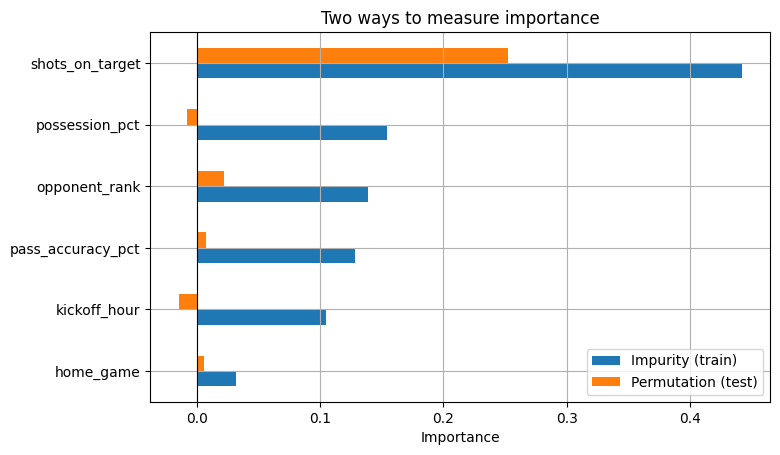

In [16]:
# Chart: impurity importance vs permutation importance
both = pd.DataFrame({"Impurity (train)": rf_importances, "Permutation (test)": perm_importances})
both = both.sort_values("Impurity (train)")

both.plot(kind="barh", figsize=(8, 4.8))
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Importance")
plt.title("Two ways to measure importance")
plt.savefig("images/impurity_vs_permutation.png", dpi=150, bbox_inches="tight")
plt.show()

## Practice Exercise
**Your turn (Practice).** Using the data already in this notebook:
1. Fit `RandomForestClassifier(n_estimators=300, random_state=42, oob_score=True)`.
2. Print its OOB score and test accuracy.
3. Print the top 3 features by `feature_importances_`.
4. Is the top feature the same as with 100 trees?

In [17]:
# Your attempt here

In [18]:
# Worked answer
rf300 = RandomForestClassifier(n_estimators=300, random_state=42, oob_score=True)
rf300.fit(X_train, y_train)

print("OOB score:     ", round(rf300.oob_score_, 3))
print("Test accuracy: ", round(rf300.score(X_test, y_test), 3))

imp300 = pd.Series(rf300.feature_importances_, index=X.columns).sort_values(ascending=False)
print(imp300.head(3).round(3))
print("Same top feature as 100 trees:", imp300.index[0] == rf_importances.index[0])

OOB score:      0.768
Test accuracy:  0.76
shots_on_target    0.441
possession_pct     0.155
opponent_rank      0.141
dtype: float64
Same top feature as 100 trees: True


## Mini Challenge
**Tune the forest, then explain it.** Compare `max_depth` in `[3, 5, 8, None]` with 5-fold CV (on the training set only), retrain with the best one, and report:
1. the best depth and its mean CV accuracy,
2. test accuracy,
3. the top 3 features by **permutation importance** on the test set.

In [19]:
# Mini Challenge solution
depths = [3, 5, 8, None]
cv_means = []
for d in depths:
    m = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=42)
    cv_means.append(cross_val_score(m, X_train, y_train, cv=5).mean())
    print("max_depth", d, "| mean CV accuracy:", round(cv_means[-1], 3))

best_depth = depths[int(np.argmax(cv_means))]
print("\nBest depth by CV:", best_depth)

best_rf = RandomForestClassifier(n_estimators=100, max_depth=best_depth, random_state=42)
best_rf.fit(X_train, y_train)
print("Test accuracy:", round(best_rf.score(X_test, y_test), 3))

best_perm = permutation_importance(best_rf, X_test, y_test, n_repeats=20, random_state=42)
best_perm = pd.Series(best_perm.importances_mean, index=X.columns).sort_values(ascending=False)
print(best_perm.head(3).round(3))

max_depth 3 | mean CV accuracy: 0.787


max_depth 5 | mean CV accuracy: 0.773


max_depth 8 | mean CV accuracy: 0.771


max_depth None | mean CV accuracy: 0.792

Best depth by CV: None
Test accuracy: 0.76


shots_on_target      0.252
opponent_rank        0.022
pass_accuracy_pct    0.007
dtype: float64


## Summary
- `RandomForestClassifier(n_estimators=100, random_state=42)` fits and predicts like every other sklearn model, and does the whole bagging + feature randomness recipe from Day 60 for us.
- On the same split, the forest scored higher on the test set than a single fully grown tree (0.760 vs 0.672), and its 5-fold CV mean was higher too (0.792 vs 0.731).
- **OOB score** (0.781) gave a free validation estimate close to the test accuracy (0.760), with no extra split.
- `feature_importances_` put `shots_on_target` clearly first, and the top feature stayed the same across seeds. Averaging many trees made the importances steadier than the single-tree version.
- **The catch:** the forest gave the deliberately useless `kickoff_hour` an impurity importance of 0.105, higher than `home_game` (0.032), which genuinely affects results. Permutation importance on the test set put `kickoff_hour` below zero (pure noise). Use both, and treat impurity importance as a rough guide.
- **Next: Day 62 — Cross-Validation: K-Fold deep dive.**